# PART A

## Q1

In [12]:
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

### 1a: Total folder size

The total data size is 4.2 terabytes

In [2]:
ls -lstrh /mnt/data/MetService_WRF/ | grep total

total 4.2T


### 1b: Total file count

There are 2,773 data files in total

In [3]:
ls /mnt/data/MetService_WRF/*.nc | wc -l

2773


## Q2

### 2a: The temperature variable is recorded at 10 height levels

This can be seen by viewing the dimensions of the dataset.

In [70]:
# a. Temperature has 10 height levels
ds_T  = xr.open_dataset("/mnt/data/MetService_WRF/T_20200101000000.nc")
ds_T.sizes['height']

10

### 2b: Relative humidity for January 2010 in Gore Bay

In [74]:
# Define the target location for re-use later
GORE_BAY = { 'lat': -42.85939386667443, 'lon': 173.30867342397124 }

# Read in the relative humidity data for Jan 2010 for use in the following cells
jan2010_RH = xr.open_dataset("/mnt/data/MetService_WRF/RH_20100101000000.nc")

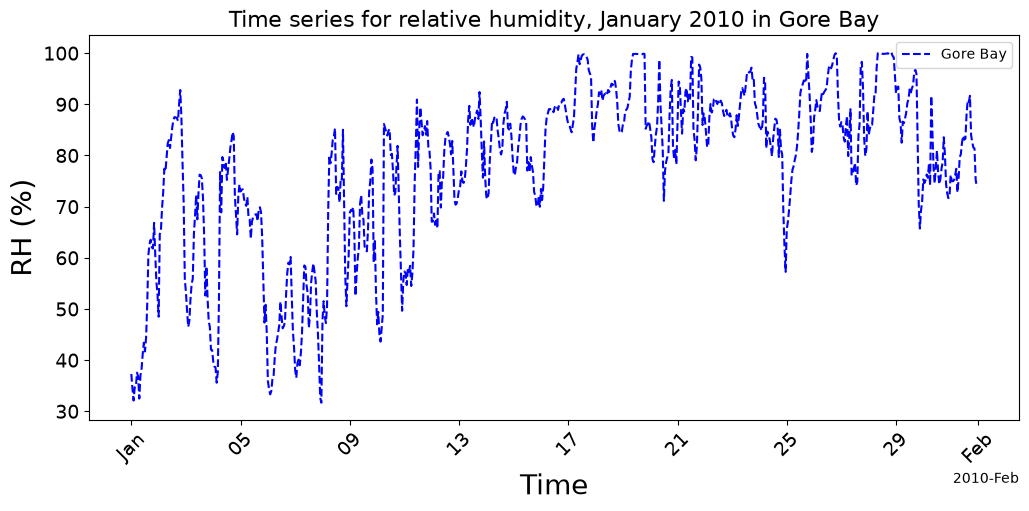

In [75]:
# Select the data closest to the target location
selection = jan2010_RH.RH.sel(lat=GORE_BAY['lat'], lon=GORE_BAY['lon'], method="nearest")

# Create the plot
selection.plot(linestyle="dashed",color="blue", label="Gore Bay", figsize=(12,5))
plt.xlabel("Time",fontsize=20)
plt.ylabel("RH (%)",fontsize=20)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14,rotation=0)
plt.title("Time series for relative humidity, January 2010 in Gore Bay",fontsize=16)
plt.legend()
plt.show()

### 2c: Temperature at 20m height, January 2010 in Gore Bay

In [76]:
# Read in the temperature data for Jan 2010 for use in the following cells
jan2010_T = xr.open_dataset("/mnt/data/MetService_WRF/T_20100101000000.nc")

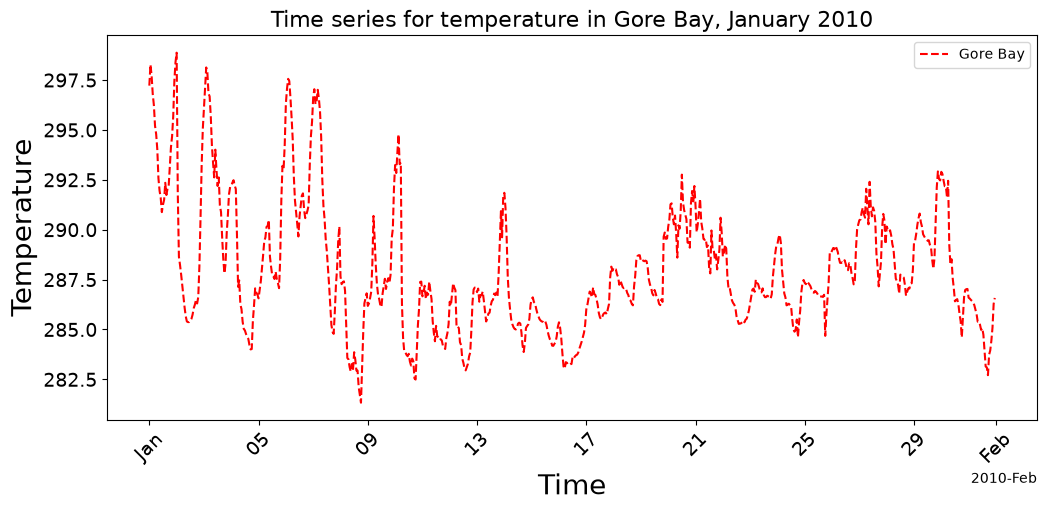

In [77]:
# Select the data closest to the target location, at 20m height
selection = jan2010_T.T.sel(height=20, lat=GORE_BAY['lat'], lon=GORE_BAY['lon'], method="nearest")

# Create the plot
selection.plot(linestyle="dashed",color="red", label="Gore Bay", figsize=(12,5))
plt.xlabel("Time",fontsize=20)
plt.ylabel("Temperature",fontsize=20)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14,rotation=0)
plt.title("Time series for temperature in Gore Bay, January 2010",fontsize=16)
plt.legend()
plt.show()

### 2d: Humidity and temperature, Jan 3-4 2010, in Gore Bay

In [78]:
# Define the start & end date here for re-use later
start_date = "2010-01-03"
end_date = "2010-01-04"

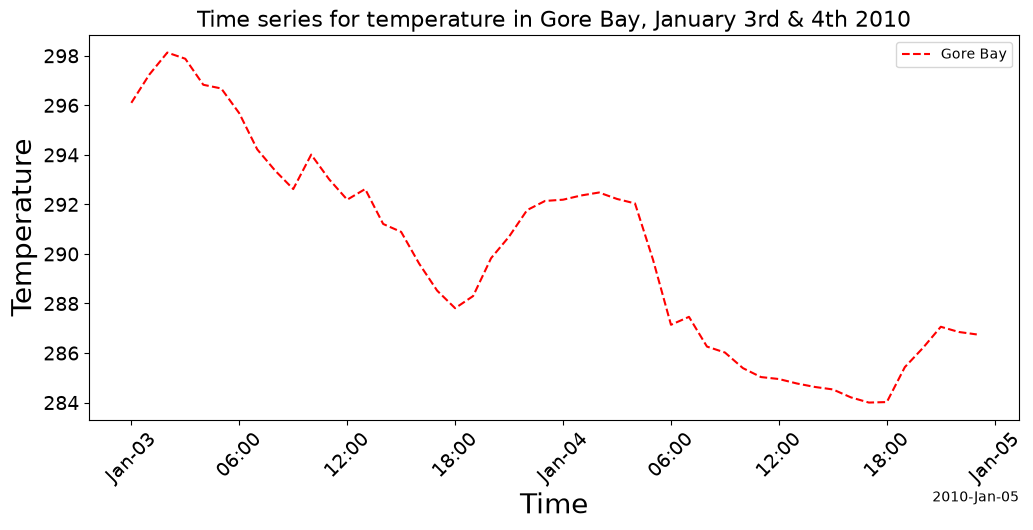

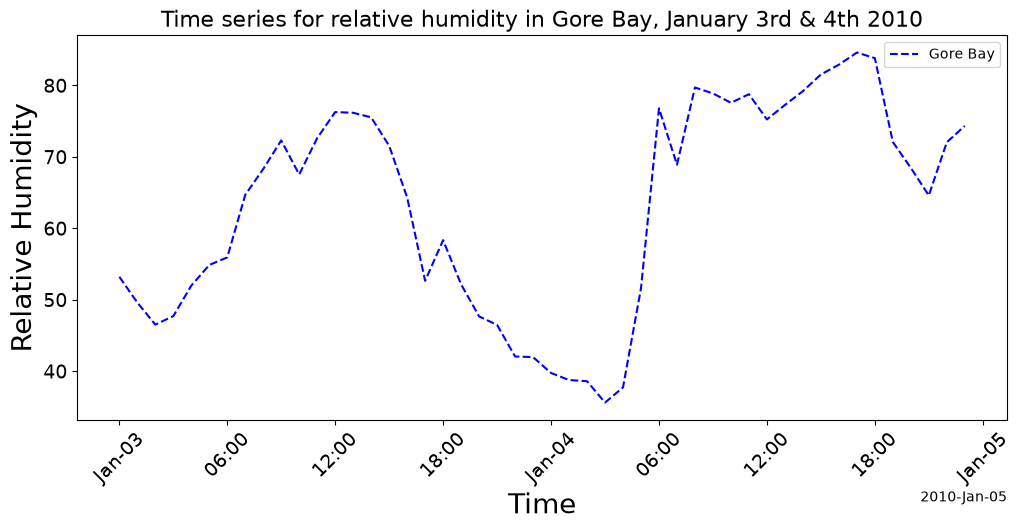

In [79]:
# Create a 2-day time slice from the temperature data and do a sanity check - there should be 48 time values
time_slice_T = jan2010_T.sel(time=slice(start_date, end_date))
assert(time_slice_T.sizes['time'] == 48)

# Then extract temperature data for the lat & lon positions closest to Gore Bay, at 20m height
selection_T = time_slice_T.sel(height=20, lat=GORE_BAY['lat'], lon=GORE_BAY['lon'], method="nearest")

# Plot the temperature data
selection_T.to_dataarray().plot(linestyle="dashed",color="red", label="Gore Bay", figsize=(12,5))
plt.xlabel("Time",fontsize=20)
plt.ylabel("Temperature",fontsize=20)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14,rotation=0)
plt.title("Time series for temperature in Gore Bay, January 3rd & 4th 2010",fontsize=16)
plt.legend()
plt.show()

# Create the 2-day time slice from relative humidity data & do a sanity check - there should be 48 time values
time_slice_RH = jan2010_RH.sel(time=slice(start_date, end_date))
assert(time_slice_RH.sizes['time'] == 48)

# Then extract relative humidity data for the lat & lon positions closest to Gore Bay
selection_RH = time_slice_RH.sel(lat=GORE_BAY['lat'], lon=GORE_BAY['lon'], method="nearest")

# Plot the relative humidity data
selection_RH.to_dataarray().plot(linestyle="dashed",color="blue",label="Gore Bay",figsize=(12,5))
plt.xlabel("Time",fontsize=20)
plt.ylabel("Relative Humidity",fontsize=20)
plt.xticks(fontsize=14,rotation=45)
plt.yticks(fontsize=14,rotation=0)
plt.title("Time series for relative humidity in Gore Bay, January 3rd & 4th 2010",fontsize=16)
plt.legend()
plt.show()


# PART B

## Q3

**Note:** Although not specified in the assignment, I made it possible to pass the month as an optional parameter, with January 2020 kept as the default month. This makes it possible to plot months side-by side for comparison.

### Code for function ws_monthavg_10m

In [66]:
"""
ws_monthavg_10m

Calculates the average wind speed for one month of data, at the 10m heigh
point. The return value is an xarray.DataArray with just two dimensions,
'lat' and 'lon'. Each data point is the average wind speed for one
location.

:param month: The month to calculate for, in format 'YYYYMM', eg '201402'
would return data for Feburary 2014. Defaults to January 2020.
:return: average wind speed data at 10m height, as an xarray DataArray.
"""
def ws_monthavg_10m(month='202001'):
    ds_WS_NS = xr.open_dataset(f'/mnt/data/MetService_WRF/V_{month}01000000.nc')
    ds_WS_EW = xr.open_dataset(f'/mnt/data/MetService_WRF/U_{month}01000000.nc')

    # v10 is all the V (north/south) wind speeds at height=10m
    v10 = ds_WS_NS.sel(height='10').V
    # u10 is all the U (east/west) wind speeds at height=10m
    u10 = ds_WS_EW.sel(height='10').U

    # square both values
    usqr = u10 ** 2
    vsqr = v10 ** 2

    # Wind speed calculation is the square root of the sum of the squares
    ws = np.sqrt(usqr + vsqr)
    
    # Each value in ws now is the effective wind speed (in whatever direction) at each time point & location.
    # Return the average wind speed value across time. The returned dataset only has lat and lon dimensions.
    # So each value is the average wind speed for the given month, at that lat/lon location
    avg = ws.mean(dim='time')
    return avg

### Example output for ws_monthavg_10m

When run with no parameter, the function returns data for January 2020.

In [62]:
ws_monthavg_10m()

<xarray.DataArray (lat: 508, lon: 472)> Size: 2MB
array([[9.94541664, 9.94988791, 9.95033679, ..., 7.16918712, 7.16388454,
        7.16151033],
       [9.92571574, 9.93044655, 9.93355247, ..., 7.15861709, 7.15010785,
        7.14541087],
       [9.90635401, 9.91207694, 9.91635833, ..., 7.14959074, 7.14425846,
        7.14282478],
       ...,
       [4.77051368, 4.76588808, 4.76681819, ..., 5.89461603, 5.89049546,
        5.88176939],
       [4.76908202, 4.76519199, 4.76081627, ..., 5.88349953, 5.88130408,
        5.87275031],
       [4.75502261, 4.75294587, 4.75072156, ..., 5.8691994 , 5.86566143,
        5.85805697]], shape=(508, 472))
Coordinates:
  * lat      (lat) float64 4kB -48.0 -47.97 -47.94 ... -34.06 -34.03 -34.01
  * lon      (lon) float64 4kB 166.0 166.0 166.1 166.1 ... 178.9 179.0 179.0
    height   float64 8B 10.0

## Q4

**Note:** As for `ws_monthavg_10m`, this function can also take an optional month parameter, so that different months can be plotted and compared.

### Code for function ws_monthavg_10m_map

In [80]:
"""
ws_monthavg10_map

Calls ws_monthavg_10m to get the average wind speeds from the data
set, and plots that data on a contour map.

:param month: The month to calculate for, in format 'YYYYMM', eg '202002'
would return data for Feburary 2020. Defaults to January 2020.
:param cmap: The colourmap to use. Defaults to Viridis.
:param vmin: Minimum wind speed value to show. Defaults to None (shows
all values).
:param vmax: Maximum wind speed value to show. Defaults to None (shows
all values).
:return: average wind speed data at 10m height, as an xarray DataArray.
"""
def ws_monthavg10m_map(month='202001', cmap='viridis', vmin=None, vmax=None):
    # Call ws_monthavg_10m to calculate the averages. Each value is the average wind speed at one lat/lon position.
    avg = ws_monthavg_10m(month)

    fig, ax = plt.subplots(subplot_kw={'projection':ccrs.PlateCarree()})
        
    # Map the values at their positions
    avg.plot.contourf(ax=ax, x='lon', y='lat', cmap=cmap, vmin=vmin, vmax=vmax, cbar_kwargs={'label': 'Average wind speed (m/s)'})
    
    # Add coastline
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    
    # Set the title to include the month parameter
    ax.set_title(f'Wind speed at 10m above ground level for {month}\n')
    
    # Add grid lines to the bottom and the left of the plot
    ax.gridlines(
        draw_labels={"bottom": "x", "left": "y"},
        dms=True,
        x_inline=False,
        y_inline=False,
    )
    
    plt.show()   


### Example usage with no parameters

Running the function with no parameters uses the default settings:  month = January 2020, colour map = Viridis, vmin and vmax = None.

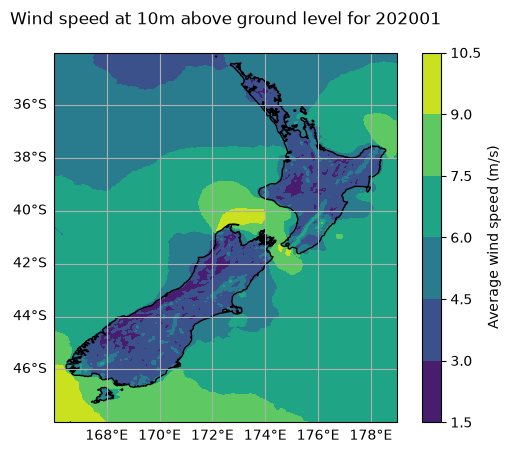

In [65]:
ws_monthavg10m_map()

### Example usage with parameters

An example of passing a different month, and different colour map.

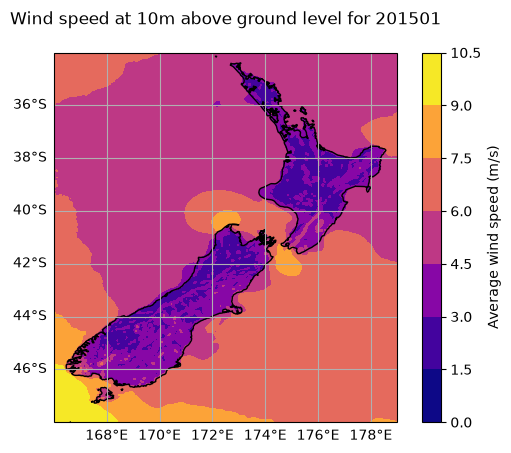

In [64]:
ws_monthavg10m_map(month='201501', cmap='plasma')

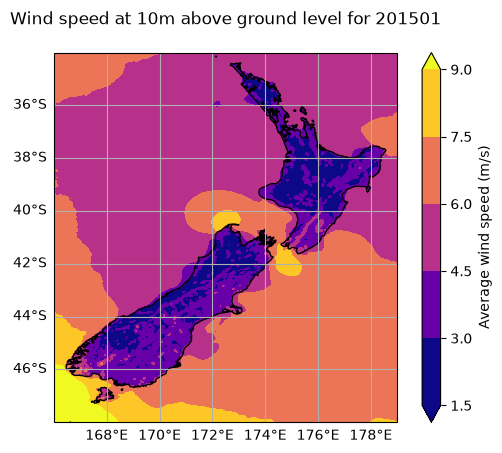

In [69]:
ws_monthavg10m_map(month='201501', cmap='plasma', vmin=2.5, vmax=9.0)

The maps for both date ranges highlight three areas that have the highest average windspeed (at the southern ends of each island and around Farewell Spit), and generally higher average speeds out at sea than over land - which was what I would expect.